# 07 · Participant-level robustness

This notebook checks whether the word-level reading-time prediction results also hold across individual participants. Reviewers may ask whether the aggregate RT result is driven by a small subset of readers, so this notebook treats each participant as a robustness unit.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir() and (p / "results").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import *

P = paths(ROOT)
FIG = P["figures"]
set_style()
pd.set_option("display.precision", 3)

MIN_TRIALS = 500
PRIMARY = {"provo": "L01", "natural_stories": "L08"}

## What this checks

The main analysis uses aggregate word-level RT. Here, I keep the trained word-level predictions fixed and evaluate them against **individual participant trials**.

For each participant, I compare:

- the surprisal-baseline prediction
- the dense or SAE prediction from the selected primary hook

The participant-level score is:

> ΔR² = R²(model prediction on that participant’s trials) − R²(surprisal baseline prediction on that participant’s trials)

Positive values mean the representation improves prediction for that participant. This is not a full mixed-effects model, but it is a useful robustness check: the aggregate result is more convincing if many individual readers show the same direction.

In [2]:
def participant_trials(corpus):
    path = ROOT / "data/prepared_v2" / corpus / f"{corpus}_participants.csv"
    df = pd.read_csv(path)
    if "row_uid" not in df.columns:
        df["row_uid"] = corpus + ":" + df["text_id"].astype(int).astype(str) + ":" + df["word_position"].astype(int).astype(str)

    if corpus == "provo":
        keep = df["analysis_RT"].notna() & (df["analysis_RT"] > 0)
        if "rt_status" in df.columns:
            keep &= df["rt_status"].eq("included")
        df = df.loc[keep].copy()
        df["trial_log_rt"] = np.log(df["analysis_RT"].astype(float))
    else:
        df = df.loc[df["raw_RT"].notna() & (df["raw_RT"] > 0)].copy()
        df["trial_log_rt"] = np.log(df["raw_RT"].astype(float))

    return df[["participant_id", "row_uid", "text_id", "word_position", "word", "trial_log_rt"]]

def prediction_file(corpus, kind, rep):
    hook = PRIMARY[corpus]
    return ROOT / "results/sae_regression_v2" / corpus / kind / hook / rep / "predictions.csv"

def participant_scores(corpus, kind, rep):
    trials = participant_trials(corpus)
    pred = pd.read_csv(prediction_file(corpus, kind, rep))[["row_uid", "prediction", "baseline_prediction"]]
    merged = trials.merge(pred, on="row_uid", how="inner")
    rows = []
    for pid, g in merged.groupby("participant_id"):
        y = g["trial_log_rt"].to_numpy(float)
        baseline = g["baseline_prediction"].to_numpy(float)
        model = g["prediction"].to_numpy(float)
        denom = float(np.sum((y - y.mean()) ** 2))
        if denom <= 0:
            continue
        sse_base = float(np.sum((y - baseline) ** 2))
        sse_model = float(np.sum((y - model) ** 2))
        rows.append({
            "corpus": corpus,
            "kind": kind,
            "representation": rep,
            "hook": PRIMARY[corpus],
            "participant_id": pid,
            "n_trials": len(g),
            "baseline_r2_pp": 100 * (1 - sse_base / denom),
            "model_r2_pp": 100 * (1 - sse_model / denom),
            "delta_r2_pp": 100 * (sse_base - sse_model) / denom,
        })
    return pd.DataFrame(rows)

score_frames = []
for corpus in CORPORA:
    for kind in ["prefix", "post"]:
        for rep in ["dense", "sae"]:
            score_frames.append(participant_scores(corpus, kind, rep))
scores = pd.concat(score_frames, ignore_index=True)
scores["Dataset"] = scores.corpus.map(lambda c: CORPUS_LABELS[c].split(" ·")[0])
scores["State"] = scores.kind.map(STATE_LABELS)
scores["Representation"] = scores.representation.map(REP_LABELS)
scores.head()

,corpus,kind,representation,hook,participant_id,n_trials,baseline_r2_pp,model_r2_pp,delta_r2_pp,Dataset,State,Representation
0,provo,prefix,dense,L01,Sub01,1907,0.131,0.424,0.294,Provo,Before word,Dense state
1,provo,prefix,dense,L01,Sub02,2158,-7.246,-7.101,0.144,Provo,Before word,Dense state
2,provo,prefix,dense,L01,Sub03,2120,-5.194,-5.222,-0.027,Provo,Before word,Dense state
3,provo,prefix,dense,L01,Sub04,1788,-3.213,-3.187,0.026,Provo,Before word,Dense state
4,provo,prefix,dense,L01,Sub05,1666,-0.982,-0.912,0.071,Provo,Before word,Dense state


## Participant coverage

The main robustness summary below uses participants with at least `MIN_TRIALS` usable trials. This avoids letting very short Natural Stories records dominate participant-level percentages.

Dataset,participants,min,median,mean,max,participants ≥ 500 trials
Natural Stories,180,8,5045.500000,4716.000000,10255,169
Provo,84,1139,1844.000000,1828.200000,2314,84


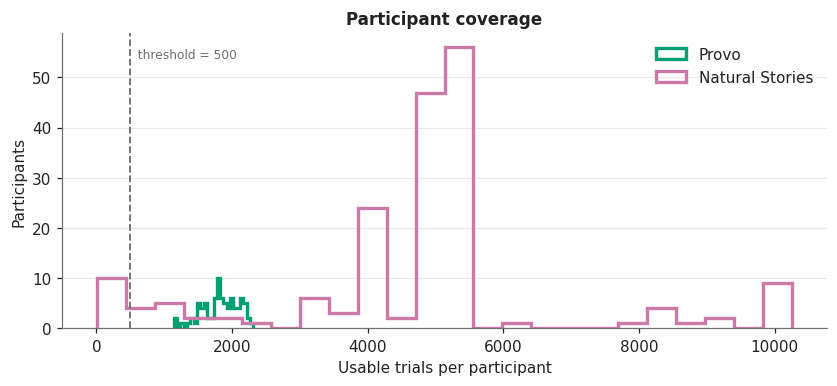

In [3]:
coverage = (scores.drop_duplicates(["corpus", "participant_id"])[["corpus", "participant_id", "n_trials"]]
            .assign(Dataset=lambda d: d.corpus.map(lambda c: CORPUS_LABELS[c].split(" ·")[0])))
coverage_summary = coverage.groupby("Dataset").n_trials.agg(
    participants="count", min="min", median="median", mean="mean", max="max"
).reset_index()
coverage_summary["participants ≥ 500 trials"] = coverage.groupby("Dataset").n_trials.apply(lambda s: int((s >= MIN_TRIALS).sum())).values
display(focus_table(coverage_summary.round(1), important=["participants", "participants ≥ 500 trials"],
                    caption="Participant coverage before the robustness threshold."))

fig, ax = plt.subplots(figsize=(7.5, 3.4), layout="constrained")
for corpus in CORPORA:
    g = coverage[coverage.corpus == corpus]
    ax.hist(g.n_trials, bins=24, histtype="step", lw=2.2, color=CORPUS_COLORS[corpus],
            label=CORPUS_LABELS[corpus].split(" ·")[0])
ax.axvline(MIN_TRIALS, color=MUTED, ls="--", lw=1.2)
ax.text(MIN_TRIALS, ax.get_ylim()[1] * 0.95, f"  threshold = {MIN_TRIALS}", va="top", color=MUTED, fontsize=8)
ax.set_xlabel("Usable trials per participant")
ax.set_ylabel("Participants")
ax.set_title("Participant coverage")
ax.grid(axis="y", color=GRID)
ax.legend()
save_figure(fig, FIG, "07_participant_coverage")
plt.show()

In [4]:
def boot_ci(values, seed=42, n_boot=5000):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    means = np.array([rng.choice(values, len(values), replace=True).mean() for _ in range(n_boot)])
    return values.mean(), np.percentile(means, 2.5), np.percentile(means, 97.5)

main = scores[scores.n_trials >= MIN_TRIALS].copy()
summary_rows = []
for (corpus, kind, rep), g in main.groupby(["corpus", "kind", "representation"]):
    mean, lo, hi = boot_ci(g.delta_r2_pp, seed=abs(hash((corpus, kind, rep))) % (2**32))
    summary_rows.append({
        "Dataset": CORPUS_LABELS[corpus].split(" ·")[0],
        "State": STATE_LABELS[kind],
        "Hook": PRIMARY[corpus],
        "Representation": REP_LABELS[rep],
        "Mean ΔR² pp": mean,
        "95% CI low": lo,
        "95% CI high": hi,
        "Median ΔR² pp": g.delta_r2_pp.median(),
        "Participants improved": f"{int((g.delta_r2_pp > 0).sum())}/{len(g)}",
        "% improved": 100 * (g.delta_r2_pp > 0).mean(),
    })
summary = pd.DataFrame(summary_rows).sort_values(["Dataset", "State", "Representation"])
display(focus_table(summary.round(2), important=["Mean ΔR² pp", "Participants improved"],
                    signed_columns=["Mean ΔR² pp", "Median ΔR² pp"],
                    caption="Participant-level robustness. Positive ΔR² means the fixed word-level model improves prediction for that participant relative to the surprisal baseline."))

Dataset,State,Hook,Representation,Mean ΔR² pp,95% CI low,95% CI high,Median ΔR² pp,Participants improved,% improved
Natural Stories,After word,L08,Dense state,-0.530000,-1.330000,0.160000,-0.060000,82/169,48.520000
Natural Stories,After word,L08,SAE features,-0.440000,-0.990000,0.080000,-0.070000,77/169,45.560000
Natural Stories,Before word,L08,Dense state,0.180000,-0.220000,0.580000,0.260000,96/169,56.800000
Natural Stories,Before word,L08,SAE features,0.330000,0.100000,0.550000,0.300000,112/169,66.270000
Provo,After word,L01,Dense state,0.240000,0.180000,0.290000,0.230000,67/84,79.760000
Provo,After word,L01,SAE features,0.560000,0.450000,0.670000,0.500000,76/84,90.480000
Provo,Before word,L01,Dense state,0.080000,0.050000,0.120000,0.080000,59/84,70.240000
Provo,Before word,L01,SAE features,0.310000,0.240000,0.380000,0.360000,67/84,79.760000


## Participant-level gain distribution

Each point is one participant. The horizontal bar shows the participant-bootstrap 95% CI for the mean. Filled markers are SAE features; open markers are dense states. The color identifies the corpus.

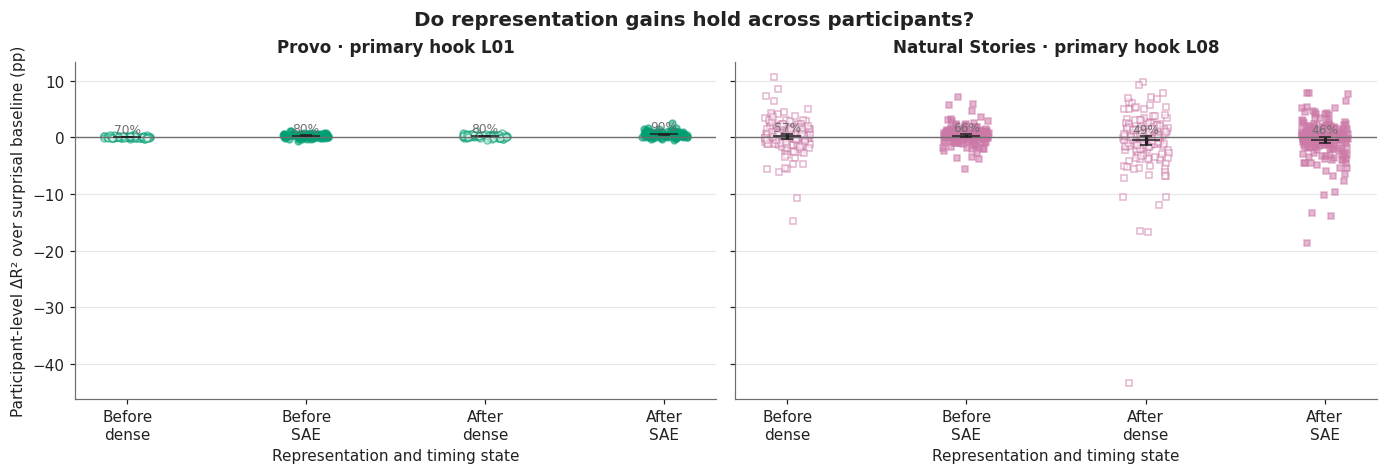

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), layout="constrained", sharey=True)
order = [("prefix", "dense"), ("prefix", "sae"), ("post", "dense"), ("post", "sae")]
labels = ["Before\ndense", "Before\nSAE", "After\ndense", "After\nSAE"]
rng = np.random.default_rng(7)

for ax, corpus in zip(axes, CORPORA):
    color = CORPUS_COLORS[corpus]
    sub = main[main.corpus == corpus]
    for i, (kind, rep) in enumerate(order):
        g = sub[(sub.kind == kind) & (sub.representation == rep)]
        x = i + rng.uniform(-0.13, 0.13, len(g))
        mfc = color if rep == "sae" else "white"
        ax.plot(x, g.delta_r2_pp, ls="", marker=CORPUS_MARKERS[corpus], color=color, mfc=mfc,
                mec=color, mew=1.0, ms=4.5, alpha=0.55)
        mean, lo, hi = boot_ci(g.delta_r2_pp, seed=100 + i)
        ax.errorbar(i, mean, yerr=[[mean - lo], [hi - mean]], color=INK, marker="_", ms=18,
                    lw=2.0, capsize=4, zorder=5)
        ax.text(i, hi + 0.05, f"{(g.delta_r2_pp > 0).mean()*100:.0f}%",
                ha="center", va="bottom", fontsize=8, color=MUTED)
    ax.axhline(0, color=MUTED, lw=0.9)
    ax.set_xticks(range(len(order)), labels)
    ax.set_title(f"{CORPUS_LABELS[corpus].split(' ·')[0]} · primary hook {PRIMARY[corpus]}")
    ax.grid(axis="y", color=GRID)
    ax.set_xlabel("Representation and timing state")
axes[0].set_ylabel("Participant-level ΔR² over surprisal baseline (pp)")
fig.suptitle("Do representation gains hold across participants?", fontsize=13, fontweight="bold")
save_figure(fig, FIG, "07_participant_level_gain_distribution")
plt.show()

## How I would describe this in the presentation

This is a robustness check, not the main model. The predictions were trained on aggregate word-level RT, then evaluated against individual participants.

A strong result means many participants have positive ΔR², not just the aggregate item means. A weak result means the aggregate model may still be useful, but I should avoid claiming uniform participant-level effects.

For a paper, the next statistical extension would be a mixed-effects model with participant random intercepts and, if stable, random slopes for surprisal or selected representation scores.